<a href="https://colab.research.google.com/github/mokhivibes/ml_course_hometasks/blob/main/SalaryExpModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/Salary_Data.csv")
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


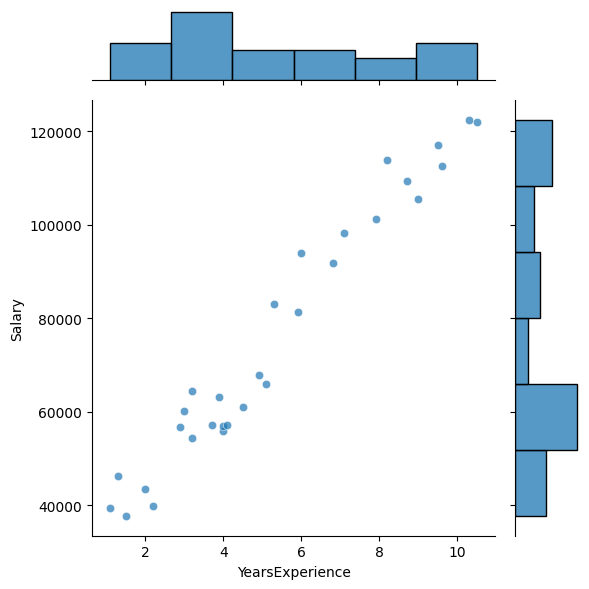

In [4]:
#EDA
sns.jointplot(x='YearsExperience', y='Salary', data=df, alpha=0.7)
plt.tight_layout()
plt.show()

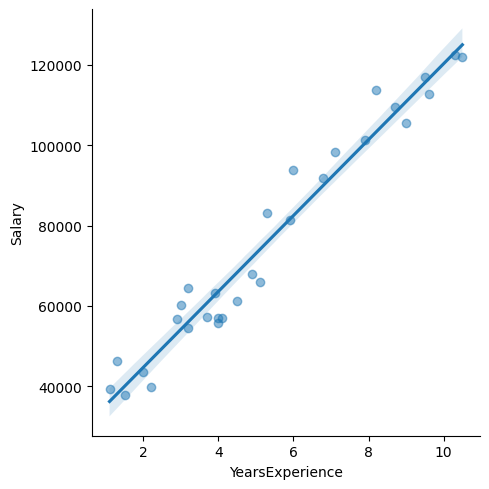

In [5]:
sns.lmplot(x = 'YearsExperience',
           y ='Salary',
           data = df,
           scatter_kws= {'alpha': 0.5})

In [6]:
from sklearn.model_selection import train_test_split


In [7]:
x= df[['YearsExperience']]
y=df['Salary']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [9]:
X_train.count()

,0
YearsExperience,24


In [10]:
#Training the model
from sklearn.linear_model import LinearRegression

lm = LinearRegression()

lm.fit(X_train, y_train)

LinearRegression()

In [11]:
lm.coef_ #=> in this dataset we have only 1 coef
cdf = pd.DataFrame(lm.coef_, x.columns, columns=['Coeff'])
print(cdf)


                       Coeff
YearsExperience  9423.815323


In [12]:
#predictions

predictions= lm.predict(X_test)
print(predictions)

[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


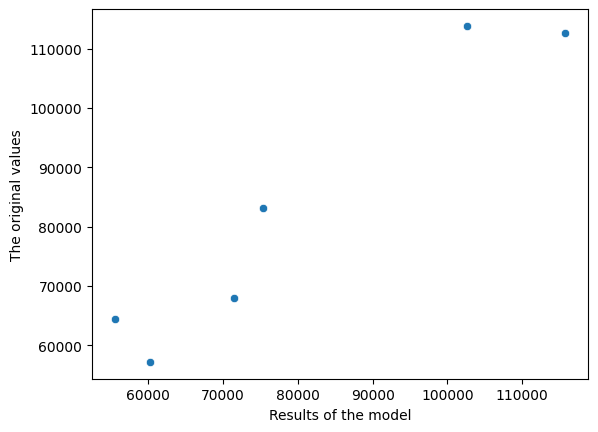

In [13]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel('Results of the model')
plt.ylabel('The original values')
plt.show()

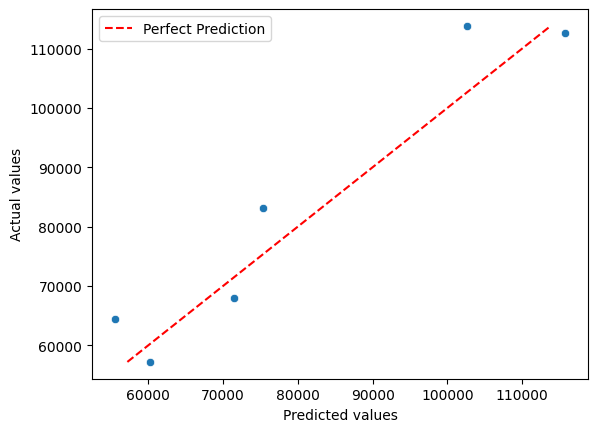

In [14]:
sns.scatterplot(x=predictions, y=y_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.legend()
plt.show()